In [ ]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.6 MB/s eta 0:00:00


# **Open YAML file**

In [ ]:
!cat "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/object_detection_Dataset/data.yaml"

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Bird', 'drone']

roboflow:
  workspace: new-workspace-x00wt
  project: drones-and-birds-0muie
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/new-workspace-x00wt/drones-and-birds-0muie/dataset/1

# **Train the YOLOv26 model**

In [ ]:
from ultralytics import YOLO

# Load the SOTA YOLO26 model
model = YOLO("yolo26n.pt")

# Train the network on your custom dataset
results = model.train(
    data="/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/object_detection_Dataset/data.yaml",
    epochs=5,
    imgsz=640,
    device='cpu'
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/object_detection_Dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2,

In [ ]:
import glob
import os

# Find all possible weights paths matching the directory pattern
weight_files = glob.glob("/content/runs/detect/train*/weights/best.pt")

if not weight_files:
    print("❌ Error: No 'best.pt' files found anywhere! Did your training script crash or get closed before finishing?")
else:
    # Sort folders to grab the latest training attempt
    latest_best_pt = max(weight_files, key=os.path.getmtime)
    print(f"🔍 Found your weights file at: {latest_best_pt}")

    # Create the backup path inside your Google Drive
    drive_save_path = "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/trained_models"
    os.makedirs(drive_save_path, exist_ok=True)

    # Copy the file into your Drive
    destination = f"{drive_save_path}/yolo26_birds_drones.pt"
    os.system(f'cp -f "{latest_best_pt}" "{destination}"')

    if os.path.exists(destination):
        print(f"🎉 Success! Your weights are safely backed up to Drive at:\n{destination}")


🔍 Found your weights file at: /content/runs/detect/train-2/weights/best.pt
🎉 Success! Your weights are safely backed up to Drive at:
/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/trained_models/yolo26_birds_drones.pt


# **Test Model**


image 1/1 /content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/download (4).jpg: 448x640 1 drone, 189.6ms
Speed: 3.8ms preprocess, 189.6ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)


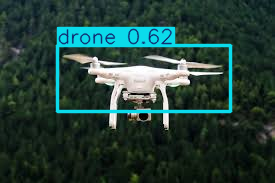

In [ ]:
from ultralytics import YOLO

# Load your custom fine-tuned weights
model = YOLO("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/trained_models/yolo26_birds_drones.pt")

# Run inference on a test image or video stream
results = model("/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/download (4).jpg", conf=0.25)

# Render and plot the custom bounding boxes
for result in results:
    result.show()


# **Streamlit**

In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.9 MB/s eta 0:00:00
--2026-05-25 06:53:09--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.5.0/cloudflared-linux-amd64 [following]
--2026-05-25 06:53:09--  https://github.com/cloudflare/cloudflared/releases/download/2026.5.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/19374280-4acc-49fd-a5af-eb955320fe42?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-25T07%3A45%3A28Z&rscd=attachment%3B+filename%3Dcl

In [ ]:
%%writefile detect.py

import streamlit as st
from ultralytics import YOLO
from PIL import Image
import os

# Page Configuration
st.set_page_config(
    page_title="Aerial Object Detector",
    page_icon="🦅",
    layout="wide"
)

# Application Header
st.title("🦅 or 🛰️ Aerial Object Detection: Birds & Drones")
st.write("Upload an aerial or field image to detect birds and drones using your fine-tuned YOLO model.")

# Path to your saved weights in Google Drive
# Note: If running locally on your computer, update this path to where you downloaded 'yolo26_birds_drones.pt'
MODEL_PATH = "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/trained_models/yolo26_birds_drones.pt"

# Cache the model loading to prevent retraining/reloading on every button click
@st.cache_resource
def load_custom_model(path):
    if not os.path.exists(path):
        st.error(f"Model file not found at: {path}. Please check your Google Drive path alignment.")
        return None
    return YOLO(path)

# Load the network
model = load_custom_model(MODEL_PATH)

if model is not None:
    # User Configuration Sidebar
    st.sidebar.header("🔧 Model Configurations")
    conf_threshold = st.sidebar.slider("Confidence Threshold", min_value=0.10, max_value=1.00, value=0.25, step=0.05)

    # File Uploader Layout
    uploaded_file = st.file_uploader("Choose an image file...", type=["jpg", "jpeg", "png", "webp"])

    if uploaded_file is not None:
        # Convert uploaded file to PIL Image format
        input_image = Image.open(uploaded_file)

        # Create columns for a side-by-side comparison interface
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("🖼️ Original Uploaded Image")
            st.image(input_image, use_container_width=True)

        with col2:
            st.subheader("🎯 Model Analytical Inference")

            # Run object detection
            with st.spinner("Processing architectural tensors..."):
                results = model.predict(source=input_image, conf=conf_threshold)

                # Extract the first result mapping frame and convert array back to image
                annotated_frame = results[0].plot()
                output_image = Image.fromarray(annotated_frame[..., ::-1]) # Convert BGR to RGB layout

            st.image(output_image, use_container_width=True)

            # Metadata analytics display metrics
            detection_count = len(results[0].boxes)
            st.success(f"Execution complete! Detected **{detection_count}** specific objects in frame.")


Overwriting detect.py


In [ ]:
!streamlit run /content/detect.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://introduced-method-approaches-doctor.trycloudflare.com
